# (노트) Fashion_MNIST (2)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [데이터과학]

## imports 

In [1]:
import tensorflow as tf 
import tensorflow.experimental.numpy as tnp

In [2]:
tnp.experimental_enable_numpy_behavior()

In [3]:
import matplotlib.pyplot as plt

## 올바른 데이터 정리

`-` fashion mnist data 다시 불러오자 

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [5]:
x_train.shape

(60000, 28, 28)

- 이미지는 원래 가로픽셀 * 세로픽셀 * 3 이어야 한다. (색을 표현하는 basis는 빨,녹,파)

`-` 따라서 이미지의 차원이 단지 (28,28)이라는 것은 흑백이미지라는 뜻이다. 

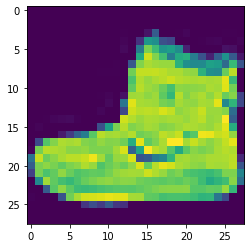

In [6]:
plt.imshow(x_train[0]) 

- 아닌데요?! 칼라인데요?! -> 흑백이다. 그냥 밝을수록 노란색, 어두울수록 남색으로 표현한것 뿐임 (colormap이 viridis일 뿐임)

`-` 일반적으로 분석할 이미지는 칼라를 의미하는 채널도 포함할테니 아래와 같이 자료형을 정리하는게 일반적으로 이미지 자료를 분석하는 정석적인 처리방법이다. 

In [7]:
X = tf.constant(x_train.reshape(-1,28,28,1),dtype=tf.float64)
y = tf.keras.utils.to_categorical(y_train)
XX = tf.constant(x_test.reshape(-1,28,28,1),dtype=tf.float64)
yy = tf.keras.utils.to_categorical(y_test)

2022-05-11 09:24:57.787148: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [8]:
X.shape, XX.shape

(TensorShape([60000, 28, 28, 1]), TensorShape([10000, 28, 28, 1]))

- keras에서 이미지자료는 (관측치수,픽셀,픽셀,채널)과 같은 형식을 가진다. 
- 예를들어 256*256 size인 칼라이미지(채널수=3)가 10개 있다면 X.shape은 (10,256,256,3)이다. 

## 올바른 데이터일경우 DNN 쓰기 

### (예제1) X -> Dense(30,relu) -> Dense(10,softmax):=> y 

`-` 이러한 아키텍처를 돌리기 위해서는 X의 shape을 미리 바꿔야 했었다. 혹시 바꾸지 않는 방법도 있을까? 

`-` tf.keras.layers.Flatten()

In [9]:
flttn = tf.keras.layers.Flatten()

In [10]:
flttn

- type: flatten <- 머 어쩌란거야..

In [11]:
set(dir(flttn)) & {'__call__'}

{'__call__'}

- call이 있음 -> 써보자

In [12]:
X.shape

TensorShape([60000, 28, 28, 1])

In [13]:
flttn(X) # 오..? 

<tf.Tensor: shape=(60000, 784), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

펴진다? 즉 X.reshape(-1,784)와 같은 기능!

`-` 근데 이거 레이어다? 즉 네트워크에 add 할 수 있다는 의미!

`-` 그렇다면 아래와 같이 예제를 풀어도 괜찮겠다.

In [14]:
tf.random.set_seed(43052)
net1 = tf.keras.Sequential()
net1.add(tf.keras.layers.Flatten())
net1.add(tf.keras.layers.Dense(30,activation='relu'))
net1.add(tf.keras.layers.Dense(10,activation='softmax'))
net1.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net1.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 648us/step - loss: 2.5204 - accuracy: 0.4137
Epoch 2/5
1875/1875 [==============================] - 1s 655us/step - loss: 1.1234 - accuracy: 0.5701
Epoch 3/5
1875/1875 [==============================] - 1s 659us/step - loss: 0.8432 - accuracy: 0.6826
Epoch 4/5
1875/1875 [==============================] - 1s 658us/step - loss: 0.7400 - accuracy: 0.7095
Epoch 5/5
1875/1875 [==============================] - 1s 643us/step - loss: 0.7107 - accuracy: 0.7185


`-` 관찰

In [15]:
net1.layers

In [16]:
net1.layers[0](X) # 레이어를 통과하는 순간 전처리!

<tf.Tensor: shape=(60000, 784), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

In [17]:
net1.layers[1](net1.layers[0](X)) # 출력이 30이니까~ + 렐루를 거쳐서 0또는 양수인 모습!

<tf.Tensor: shape=(60000, 30), dtype=float32, numpy=
array([[  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     , 715.2471 ,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,  79.66721,
          0.     ],
       ...,
       [  0.     ,   0.     ,   0.     , ...,   0.     , 242.56471,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     , 188.02762,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ]], dtype=float32)>

In [18]:
net1.layers[2](net1.layers[1](net1.layers[0](X))) # 최종출력 10차원, 각각은 확률을 의미하게 된다. 

<tf.Tensor: shape=(60000, 10), dtype=float32, numpy=
array([[0.0000000e+00, 6.7356038e-26, 0.0000000e+00, ..., 5.2073701e-05,
        0.0000000e+00, 9.9930179e-01],
       [9.2621958e-01, 3.4630163e-13, 2.0590976e-08, ..., 0.0000000e+00,
        2.7325509e-06, 0.0000000e+00],
       [1.4886163e-01, 1.1000717e-02, 7.1487971e-02, ..., 1.1439485e-20,
        2.4407296e-04, 2.7439104e-14],
       ...,
       [5.0350726e-02, 3.1092446e-02, 8.0807640e-06, ..., 0.0000000e+00,
        1.1398913e-14, 0.0000000e+00],
       [2.9261106e-01, 4.4528202e-05, 1.6416300e-02, ..., 2.3381514e-19,
        1.0894101e-02, 2.7302613e-12],
       [8.8483744e-36, 0.0000000e+00, 0.0000000e+00, ..., 2.3460865e-08,
        7.4954237e-17, 3.8124639e-08]], dtype=float32)>

`-` (참고) metrics=['accuracy'] 대신에 이렇게 해도된다~

In [19]:
tf.random.set_seed(43052)
net1 = tf.keras.Sequential()
net1.add(tf.keras.layers.Flatten())
net1.add(tf.keras.layers.Dense(30,activation='relu'))
net1.add(tf.keras.layers.Dense(10,activation='softmax'))
net1.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=[tf.metrics.CategoricalAccuracy()])
net1.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 1s 672us/step - loss: 2.5256 - categorical_accuracy: 0.4123
Epoch 2/5
1875/1875 [==============================] - 1s 661us/step - loss: 1.1812 - categorical_accuracy: 0.5283
Epoch 3/5
1875/1875 [==============================] - 1s 664us/step - loss: 0.9976 - categorical_accuracy: 0.5956
Epoch 4/5
1875/1875 [==============================] - 1s 665us/step - loss: 0.9263 - categorical_accuracy: 0.6220
Epoch 5/5
1875/1875 [==============================] - 1s 654us/step - loss: 0.8416 - categorical_accuracy: 0.6572


In [20]:
id(tf.metrics.CategoricalAccuracy), id(tf.keras.metrics.CategoricalAccuracy)

(94741298833824, 94741298833824)

- 주소가 똑같네요, 이게 무슨말인지 알죠?

`-` 주의사항: tf.metrics.Accuracy() 말고 tf.metrics.CategoricalAccuracy() 를 써야함

`-` (참고2) 메트릭을 추가할수도 있다 

In [21]:
tf.random.set_seed(43052)
net1 = tf.keras.Sequential()
net1.add(tf.keras.layers.Flatten())
net1.add(tf.keras.layers.Dense(30,activation='relu'))
net1.add(tf.keras.layers.Dense(10,activation='softmax'))
net1.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=[tf.metrics.CategoricalAccuracy(),tf.metrics.Recall()])
net1.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 895us/step - loss: 2.5281 - categorical_accuracy: 0.4116 - recall: 0.3026
Epoch 2/5
1875/1875 [==============================] - 2s 888us/step - loss: 1.1991 - categorical_accuracy: 0.5196 - recall: 0.4105
Epoch 3/5
1875/1875 [==============================] - 2s 848us/step - loss: 1.0037 - categorical_accuracy: 0.5962 - recall: 0.4869
Epoch 4/5
1875/1875 [==============================] - 2s 862us/step - loss: 0.9160 - categorical_accuracy: 0.6299 - recall: 0.4867
Epoch 5/5
1875/1875 [==============================] - 2s 865us/step - loss: 0.8536 - categorical_accuracy: 0.6454 - recall: 0.4793


`-` 리콜을 추가하면 test set의 성능평가에도 리콜을 볼 수 있다.

In [22]:
net1.evaluate(XX,yy)

313/313 [==============================] - 0s 861us/step - loss: 0.8776 - categorical_accuracy: 0.6600 - recall: 0.4723


[0.877594530582428, 0.6600000262260437, 0.4722999930381775]

### (예제2) X -> Dense(500,relu) -> Dense(500,relu) -> Dense(10,softmax):=>y 

`-` 다른모형으로도 적합시켜보자. 

In [23]:
tf.random.set_seed(43052)
net2 = tf.keras.Sequential()
net2.add(tf.keras.layers.Flatten())
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(10,activation='softmax'))
net2.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net2.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 755us/step - loss: 2.2346 - accuracy: 0.7531
Epoch 2/5
1875/1875 [==============================] - 1s 754us/step - loss: 0.6372 - accuracy: 0.79350s - loss: 0.6557 - ac
Epoch 3/5
1875/1875 [==============================] - 1s 735us/step - loss: 0.5455 - accuracy: 0.8162
Epoch 4/5
1875/1875 [==============================] - 1s 759us/step - loss: 0.4945 - accuracy: 0.8315
Epoch 5/5
1875/1875 [==============================] - 1s 753us/step - loss: 0.4554 - accuracy: 0.8422


In [24]:
net2.fit(XX,yy)

313/313 [==============================] - 0s 1ms/step - loss: 0.5251 - accuracy: 0.8227


`-` 좀 더 돌려보자. 

In [25]:
tf.random.set_seed(43052)
net2 = tf.keras.Sequential()
net2.add(tf.keras.layers.Flatten())
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(10,activation='softmax'))
net2.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net2.fit(X,y,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 2s 788us/step - loss: 2.2539 - accuracy: 0.7484
Epoch 2/10
1875/1875 [==============================] - 1s 789us/step - loss: 0.6322 - accuracy: 0.7977
Epoch 3/10
1875/1875 [==============================] - 1s 755us/step - loss: 0.5509 - accuracy: 0.8110
Epoch 4/10
1875/1875 [==============================] - 1s 774us/step - loss: 0.4933 - accuracy: 0.8291
Epoch 5/10
1875/1875 [==============================] - 1s 777us/step - loss: 0.4646 - accuracy: 0.8407
Epoch 6/10
1875/1875 [==============================] - 1s 780us/step - loss: 0.4475 - accuracy: 0.8458
Epoch 7/10
1875/1875 [==============================] - 1s 773us/step - loss: 0.4265 - accuracy: 0.8520
Epoch 8/10
1875/1875 [==============================] - 1s 757us/step - loss: 0.4166 - accuracy: 0.8553
Epoch 9/10
1875/1875 [==============================] - 1s 774us/step - loss: 0.3995 - accuracy: 0.8575
Epoch 10/10
1875/1875 [==============================] - 1s 778u

In [26]:
net2.fit(XX,yy)

313/313 [==============================] - 0s 1ms/step - loss: 0.4628 - accuracy: 0.8439


`-` 이 이상은 비효율적인듯.. 

### 더 좋은 모형을 만들고 싶은데.. 

#### 아주 복잡한 DNN

`-` 무지성: 아 몰라 딥러닝이 해주겠지

In [27]:
tf.random.set_seed(43052)
net3 = tf.keras.Sequential()
net3.add(tf.keras.layers.Flatten())
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(10,activation='softmax'))
net3.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net3.fit(X,y,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.9828 - accuracy: 0.7951
Epoch 2/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.4500 - accuracy: 0.8395
Epoch 3/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.4131 - accuracy: 0.8541
Epoch 4/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3930 - accuracy: 0.8611
Epoch 5/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3768 - accuracy: 0.8670
Epoch 6/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3571 - accuracy: 0.8736
Epoch 7/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3426 - accuracy: 0.8777
Epoch 8/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3321 - accuracy: 0.8806
Epoch 9/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3323 - accuracy: 0.8824
Epoch 10/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.311

In [28]:
net3.evaluate(XX,yy)

313/313 [==============================] - 0s 897us/step - loss: 0.4160 - accuracy: 0.8631


[0.41601669788360596, 0.863099992275238]

In [29]:
net2.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 784)               0         
                                                                 
 dense_9 (Dense)             (None, 500)               392500    
                                                                 
 dense_10 (Dense)            (None, 500)               250500    
                                                                 
 dense_11 (Dense)            (None, 10)                5010      
                                                                 
Total params: 648,010
Trainable params: 648,010
Non-trainable params: 0
_________________________________________________________________


In [30]:
net3.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_6 (Flatten)         (None, 784)               0         
                                                                 
 dense_12 (Dense)            (None, 500)               392500    
                                                                 
 dense_13 (Dense)            (None, 500)               250500    
                                                                 
 dense_14 (Dense)            (None, 500)               250500    
                                                                 
 dense_15 (Dense)            (None, 500)               250500    
                                                                 
 dense_16 (Dense)            (None, 500)               250500    
                                                                 
 dense_17 (Dense)            (None, 10)               

`-` 파라메터 증가대비 그닥.. 

`-` 왠지 DNN계열로는 한계가 있어보인다. 

#### 발상의 전환 

`-` Flattne 레이어를 보면서 느낀점: 생각해보니까 $X \to \hat{y}$를 만드는 과정이 꼭 Full Linear Transform(Dense layer) + Activation(Activation layer)일 필요는 없잖아?  

`-` 뭐가있지? 

In [31]:
dir(tf.keras.layers)

['AbstractRNNCell',
 'Activation',
 'ActivityRegularization',
 'Add',
 'AdditiveAttention',
 'AlphaDropout',
 'Attention',
 'Average',
 'AveragePooling1D',
 'AveragePooling2D',
 'AveragePooling3D',
 'AvgPool1D',
 'AvgPool2D',
 'AvgPool3D',
 'BatchNormalization',
 'Bidirectional',
 'CategoryEncoding',
 'CenterCrop',
 'Concatenate',
 'Conv1D',
 'Conv1DTranspose',
 'Conv2D',
 'Conv2DTranspose',
 'Conv3D',
 'Conv3DTranspose',
 'ConvLSTM1D',
 'ConvLSTM2D',
 'ConvLSTM3D',
 'Convolution1D',
 'Convolution1DTranspose',
 'Convolution2D',
 'Convolution2DTranspose',
 'Convolution3D',
 'Convolution3DTranspose',
 'Cropping1D',
 'Cropping2D',
 'Cropping3D',
 'Dense',
 'DenseFeatures',
 'DepthwiseConv1D',
 'DepthwiseConv2D',
 'Discretization',
 'Dot',
 'Dropout',
 'ELU',
 'Embedding',
 'Flatten',
 'GRU',
 'GRUCell',
 'GaussianDropout',
 'GaussianNoise',
 'GlobalAveragePooling1D',
 'GlobalAveragePooling2D',
 'GlobalAveragePooling3D',
 'GlobalAvgPool1D',
 'GlobalAvgPool2D',
 'GlobalAvgPool3D',
 'GlobalM

`-` 엄청많아.. 

`-` 우리는 이중에서 2D conv, max pooling 에 관심이 있다! (이번수업은 max pooling 정도만)

#### MaxPooling2D, MaxPool2D

In [32]:
id(tf.keras.layers.MaxPooling2D), id(tf.keras.layers.MaxPool2D)

(93927771230368, 93927771230368)

`-` 테스트1: (2,2) 이미지

In [33]:
mp = tf.keras.layers.MaxPool2D() # pool size의 디폴트는 (2,2)

In [34]:
XXX = tnp.arange(1*2*2*1).reshape(1,2,2,1)
XXX

<tf.Tensor: shape=(1, 2, 2, 1), dtype=int64, numpy=
array([[[[0],
         [1]],

        [[2],
         [3]]]])>

In [35]:
XXX.reshape(1,2,2) # 채널때문에 살짝 헷갈리지만 실제로는 이렇게 생긴 이미지! 

<tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
array([[[0, 1],
        [2, 3]]])>

In [36]:
mp(XXX)

<tf.Tensor: shape=(1, 1, 1, 1), dtype=int64, numpy=array([[[[3]]]])>

`-` 테스트2: (4,4) 이미지로 변경

In [37]:
mp = tf.keras.layers.MaxPool2D() # pool size의 디폴트는 (2,2)

In [38]:
XXX = tnp.arange(1*4*4*1).reshape(1,4,4,1)
XXX,XXX.reshape(1,4,4)

(<tf.Tensor: shape=(1, 4, 4, 1), dtype=int64, numpy=
 array([[[[ 0],
          [ 1],
          [ 2],
          [ 3]],
 
         [[ 4],
          [ 5],
          [ 6],
          [ 7]],
 
         [[ 8],
          [ 9],
          [10],
          [11]],
 
         [[12],
          [13],
          [14],
          [15]]]])>,
 <tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11],
         [12, 13, 14, 15]]])>)

In [39]:
mp(XXX),mp(XXX).reshape(1,2,2)

(<tf.Tensor: shape=(1, 2, 2, 1), dtype=int64, numpy=
 array([[[[ 5],
          [ 7]],
 
         [[13],
          [15]]]])>,
 <tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[ 5,  7],
         [13, 15]]])>)

`-` 테스트3: (6,6) 이미지, size변경

In [40]:
XXX = tnp.arange(1*6*6*1).reshape(1,6,6,1)
XXX.reshape(1,6,6)

<tf.Tensor: shape=(1, 6, 6), dtype=int64, numpy=
array([[[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34, 35]]])>

In [41]:
mp(XXX).reshape(1,3,3) # 왜 (2,2)씩...? 

<tf.Tensor: shape=(1, 3, 3), dtype=int64, numpy=
array([[[ 7,  9, 11],
        [19, 21, 23],
        [31, 33, 35]]])>

In [42]:
mp3 = tf.keras.layers.MaxPool2D((3,3))
mp3(XXX).reshape(1,2,2)

<tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
array([[[14, 17],
        [32, 35]]])>

`-` 테스트4: 관측치증가

In [43]:
XXX = tnp.arange(2*4*4*1).reshape(2,4,4,1)
XXX.reshape(2,4,4)

<tf.Tensor: shape=(2, 4, 4), dtype=int64, numpy=
array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]],

       [[16, 17, 18, 19],
        [20, 21, 22, 23],
        [24, 25, 26, 27],
        [28, 29, 30, 31]]])>

In [44]:
mp(XXX).reshape(2,2,2)

<tf.Tensor: shape=(2, 2, 2), dtype=int64, numpy=
array([[[ 5,  7],
        [13, 15]],

       [[21, 23],
        [29, 31]]])>

`-` 테스트5: 채널증가

In [45]:
XXX = tnp.arange(1*4*4*3).reshape(1,4,4,3)
XXX

<tf.Tensor: shape=(1, 4, 4, 3), dtype=int64, numpy=
array([[[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[24, 25, 26],
         [27, 28, 29],
         [30, 31, 32],
         [33, 34, 35]],

        [[36, 37, 38],
         [39, 40, 41],
         [42, 43, 44],
         [45, 46, 47]]]])>

In [46]:
XXX1 = XXX[...,0]
XXX2 = XXX[...,1]
XXX3 = XXX[...,2]
XXX1,XXX2,XXX3

(<tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 0,  3,  6,  9],
         [12, 15, 18, 21],
         [24, 27, 30, 33],
         [36, 39, 42, 45]]])>,
 <tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 1,  4,  7, 10],
         [13, 16, 19, 22],
         [25, 28, 31, 34],
         [37, 40, 43, 46]]])>,
 <tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 2,  5,  8, 11],
         [14, 17, 20, 23],
         [26, 29, 32, 35],
         [38, 41, 44, 47]]])>)

In [47]:
YYY1 = mp(XXX)[...,0]
YYY2 = mp(XXX)[...,1]
YYY3 = mp(XXX)[...,2]

In [48]:
YYY1,YYY2,YYY3

(<tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[15, 21],
         [39, 45]]])>,
 <tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[16, 22],
         [40, 46]]])>,
 <tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[17, 23],
         [41, 47]]])>)

`-` 관측치와 채널은 처음에만 따져보고 외울때는 1observation/흑백 버전만 고려해도 무방! (나머지는 복붙이니까)

#### tf.keras.layers.Convolution2D

생략

`-` 테스트1

In [1]:
XXX = tnp.arange(1*4*4*1).reshape(1,4,4,1)

NameError: name 'tnp' is not defined

In [2]:
XXX.reshape(1,4,4) # 흑백이미지라 생각하자!

NameError: name 'XXX' is not defined

In [218]:
cv2d = tf.keras.layers.Conv2D(1,(2,2))

In [219]:
cv2d(XXX)

InvalidArgumentError: Exception encountered when calling layer "conv2d_23" (type Conv2D).

Value for attr 'T' of int64 is not in the list of allowed values: half, bfloat16, float, double, int32
	; NodeDef: {{node Conv2D}}; Op<name=Conv2D; signature=input:T, filter:T -> output:T; attr=T:type,allowed=[DT_HALF, DT_BFLOAT16, DT_FLOAT, DT_DOUBLE, DT_INT32]; attr=strides:list(int); attr=use_cudnn_on_gpu:bool,default=true; attr=padding:string,allowed=["SAME", "VALID", "EXPLICIT"]; attr=explicit_paddings:list(int),default=[]; attr=data_format:string,default="NHWC",allowed=["NHWC", "NCHW"]; attr=dilations:list(int),default=[1, 1, 1, 1]> [Op:Conv2D]

Call arguments received:
  • inputs=tf.Tensor(shape=(1, 4, 4, 1), dtype=int64)

- 자료형이 안맞아서 연산 안한다고함

비위를 맞춰주자

In [224]:
XXX = tnp.arange(1*4*4*1,dtype=tf.float64).reshape(1,4,4,1) 

In [225]:
XXX

<tf.Tensor: shape=(1, 4, 4, 1), dtype=float64, numpy=
array([[[[ 0.],
         [ 1.],
         [ 2.],
         [ 3.]],

        [[ 4.],
         [ 5.],
         [ 6.],
         [ 7.]],

        [[ 8.],
         [ 9.],
         [10.],
         [11.]],

        [[12.],
         [13.],
         [14.],
         [15.]]]])>

In [226]:
cv2d(XXX)

<tf.Tensor: shape=(1, 3, 3, 1), dtype=float32, numpy=
array([[[[ -4.125754 ],
         [ -5.312817 ],
         [ -6.4998803]],

        [[ -8.874006 ],
         [-10.0610695],
         [-11.248133 ]],

        [[-13.622259 ],
         [-14.809322 ],
         [-15.996386 ]]]], dtype=float32)>

- 잘계산된다. 

지금까지 코드를 정리하면

In [230]:
XXX = tnp.arange(1*4*4*1,dtype=tf.float64).reshape(1,4,4,1) ## 다시 XXX 오브젝트 생성
cv2d = tf.keras.layers.Conv2D(1,(2,2)) ## 다시 cv2d object 생성 
cv2d(XXX) ## cv2d object에 XXX 통과!

<tf.Tensor: shape=(1, 3, 3, 1), dtype=float32, numpy=
array([[[[ 6.1991124],
         [ 7.535744 ],
         [ 8.872376 ]],

        [[11.54564  ],
         [12.882272 ],
         [14.2189045]],

        [[16.892168 ],
         [18.2288   ],
         [19.565432 ]]]], dtype=float32)>

실행할때마다 결과가 다르다? -> 뭔가 랜덤으로 결정되는 부분이 있군

In [234]:
tf.random.set_seed(43052)
XXX = tnp.arange(1*4*4*1,dtype=tf.float64).reshape(1,4,4,1) ## 다시 XXX 오브젝트 생성
cv2d = tf.keras.layers.Conv2D(1,(2,2)) ## 다시 cv2d object 생성 
cv2d(XXX) ## cv2d object에 XXX 통과!

<tf.Tensor: shape=(1, 3, 3, 1), dtype=float32, numpy=
array([[[[ -4.125754 ],
         [ -5.312817 ],
         [ -6.4998803]],

        [[ -8.874006 ],
         [-10.0610695],
         [-11.248133 ]],

        [[-13.622259 ],
         [-14.809322 ],
         [-15.996386 ]]]], dtype=float32)>

- 이제 실행결과가 계속 일치함

입력과 출력을 보기 편하게 바꾸자

In [235]:
XXX.reshape(1,4,4) ## 원래 XXX 

<tf.Tensor: shape=(1, 4, 4), dtype=float64, numpy=
array([[[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]]])>

In [236]:
cv2d(XXX).reshape(1,3,3) ## 보기편하게

<tf.Tensor: shape=(1, 3, 3), dtype=float32, numpy=
array([[[ -4.125754 ,  -5.312817 ,  -6.4998803],
        [ -8.874006 , -10.0610695, -11.248133 ],
        [-13.622259 , -14.809322 , -15.996386 ]]], dtype=float32)>

??? XXX가 들어가서 뭐가 어떻게 되어서 conv2(XXX)가 되었다는거야? 

In [186]:
import numpy as np

In [237]:
tf.constant(cv2d.weights[0]).reshape(2,2)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[-0.13014299, -0.23927206],
       [-0.20175874, -0.6158894 ]], dtype=float32)>

In [238]:
0 * -0.13014299 + 1 * -0.23927206 + 4 * -0.20175874 + 5 * -0.6158894

-4.1257540200000005

- 대충 느낌옴.. 

이미지를 특정 윈도우크기로 나누고 각 픽셀에 어떠한 값을 각각 곱한 다음 다 더하는 연산이 이루어지는거 같은데?... ->  확인해보자!

In [241]:
cv2d.get_weights()

[array([[[[-0.13014299]],
 
         [[-0.23927206]]],
 
 
        [[[-0.20175874]],
 
         [[-0.6158894 ]]]], dtype=float32),
 array([0.], dtype=float32)]

In [244]:
conv2d.get_weights()[0].shape

(2, 2, 1, 1)

In [245]:
np.array([1,1,1,1],dtype=np.float32).reshape(2,2,1,1) # weights

array([[[[1.]],

        [[1.]]],


       [[[1.]],

        [[1.]]]], dtype=float32)

In [246]:
np.array([3],dtype=np.float32) # bias

array([3.], dtype=float32)

In [247]:
conv2d.set_weights([np.array([1/4,1/4,1/4,1/4],dtype=np.float32).reshape(2,2,1,1), np.array([3],dtype=np.float32)]) # 재설정

In [248]:
conv2d(XXX).reshape(1,3,3)

<tf.Tensor: shape=(1, 3, 3), dtype=float32, numpy=
array([[[ 5.5,  6.5,  7.5],
        [ 9.5, 10.5, 11.5],
        [13.5, 14.5, 15.5]]], dtype=float32)>

In [249]:
XXX.reshape(1,4,4)

<tf.Tensor: shape=(1, 4, 4), dtype=float64, numpy=
array([[[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]]])>

In [250]:
(0+1+4+5)/4+3, (1+2+5+6)/4+3 , (2+3+6+7)/4+3

(5.5, 6.5, 7.5)

In [251]:
np.array([[(0+1+4+5)/4+3, (1+2+5+6)/4+3 , (2+3+6+7)/4+3], 
[(4+5+8+9)/4+3, (5+6+9+10)/4+3 , (6+7+10+11)/4+3],
[(8+9+12+13)/4+3, (9+10+13+14)/4+3 , (10+11+14+15)/4+3]])

array([[ 5.5,  6.5,  7.5],
       [ 9.5, 10.5, 11.5],
       [13.5, 14.5, 15.5]])

**conv2d**

(1) size=(2,2)인 윈도우를 만듬. 

(2) XXX에 윈도우를 통과시켜서 (2,2)크기의 sub XXX 를 얻음. sub XXX의 각 원소에 conv2d.weights[0]의 각 원소를 element-wise하게 곱한다. 

(3) (2)의 결과를 모두 더한다. 그리고 그 결과에 다시 conv2d.weights[1]을 수행 

(4) 윈도우를 이동시키면서 반복!

이걸 컨볼루션 연산이라고 한다. 첫번째 윈도우에 한정하여 이걸 수동으로 구현하면 아래와 같다. 

In [128]:
conv2d(XXX).reshape(2,3,3)

<tf.Tensor: shape=(2, 3, 3), dtype=float32, numpy=
array([[[ 5.5,  6.5,  7.5],
        [ 9.5, 10.5, 11.5],
        [13.5, 14.5, 15.5]],

       [[21.5, 22.5, 23.5],
        [25.5, 26.5, 27.5],
        [29.5, 30.5, 31.5]]], dtype=float32)>

In [138]:
XXX[0,:2,:2,0] # subXXX

<tf.Tensor: shape=(2, 2), dtype=float64, numpy=
array([[0., 1.],
       [4., 5.]])>

In [139]:
tf.reshape(conv2d.weights[0],(2,2)) #conv2d.weights[0]의 각원소 

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[0.25, 0.25],
       [0.25, 0.25]], dtype=float32)>

In [140]:
XXX[0,:2,:2,0] * tf.reshape(conv2d.weights[0],(2,2)) # element-wise 곱

<tf.Tensor: shape=(2, 2), dtype=float64, numpy=
array([[0.  , 0.25],
       [1.  , 1.25]])>

In [141]:
tf.reduce_sum(XXX[0,:2,:2,0] * tf.reshape(conv2d.weights[0],(2,2))) # element-wise 곱 -> 합

<tf.Tensor: shape=(), dtype=float64, numpy=2.5>

In [144]:
conv2d.weights[1] # bias 

<tf.Variable 'conv2d_5/bias:0' shape=(1,) dtype=float32, numpy=array([3.], dtype=float32)>

In [145]:
tf.reduce_sum(XXX[0,:2,:2,0] * tf.reshape(conv2d.weights[0],(2,2))) + conv2d.weights[1] 

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([5.5])>

note: 컨볼루션은 결국 선형연산

`-` XXX의 관측치가 여러개라면? 

In [120]:
XXX = tnp.arange(2*4*4*1,dtype=tf.float64).reshape(2,4,4,1)

In [123]:
XXX.reshape(2,4,4)

<tf.Tensor: shape=(2, 4, 4), dtype=float64, numpy=
array([[[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]],

       [[16., 17., 18., 19.],
        [20., 21., 22., 23.],
        [24., 25., 26., 27.],
        [28., 29., 30., 31.]]])>

In [125]:
conv2d(XXX).reshape(2,3,3)

<tf.Tensor: shape=(2, 3, 3), dtype=float32, numpy=
array([[[ 5.5,  6.5,  7.5],
        [ 9.5, 10.5, 11.5],
        [13.5, 14.5, 15.5]],

       [[21.5, 22.5, 23.5],
        [25.5, 26.5, 27.5],
        [29.5, 30.5, 31.5]]], dtype=float32)>

관측치별로 컨볼루션이 적용된다 

`-` XXX의 채널이 여러개라면? -> 채널별로 cv2d 적용

`-` XXX의 관측치와 채널이 모두 여러개라면? -> 관측치별로, 채널별로 cv2d 적용 

`-` cv2d의 옵션에서 (2,2) 대신에 (3,3)을 만든다면? -> 윈도우 크기가 (3,3)으로 적용

In [149]:
cv2d_33 = tf.keras.layers.Conv2D(1,(3,3))

In [151]:
cv2d_33(XXX).reshape(2,2,2)

<tf.Tensor: shape=(2, 2, 2), dtype=float32, numpy=
array([[[-0.06342876,  0.110627  ],
        [ 0.63279593,  0.80685216]],

       [[ 2.7214684 ,  2.8955257 ],
        [ 3.4176927 ,  3.5917509 ]]], dtype=float32)>

In [156]:
tf.reduce_sum(XXX[0,:3,:3,0] * tf.reshape(cv2d_33.weights[0],(3,3))) + cv2d_33.weights[1] 

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([-0.06342894])>

In [157]:
tf.reduce_sum(XXX[0,1:4,:3,0] * tf.reshape(cv2d_33.weights[0],(3,3))) + cv2d_33.weights[1] 

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([0.63279563])>

In [158]:
tf.reduce_sum(XXX[0,0:3,1:4,0] * tf.reshape(cv2d_33.weights[0],(3,3))) + cv2d_33.weights[1] 

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([0.1106272])>

In [159]:
tf.reduce_sum(XXX[0,1:4,1:4,0] * tf.reshape(cv2d_33.weights[0],(3,3))) + cv2d_33.weights[1] 

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([0.80685177])>

`-` cv2d의 옵션에서 1 대신에 2를 설정한다면? 

In [160]:
XXX = tnp.arange(1*4*4*1,dtype=tf.float64).reshape(1,4,4,1)

In [163]:
XXX.reshape(1,4,4)

<tf.Tensor: shape=(1, 4, 4), dtype=float64, numpy=
array([[[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]]])>

In [172]:
cv2d = tf.keras.layers.Conv2D(2,(2,2))

In [174]:
cv2d.weights # 아무것도..

[]

In [175]:
cv2d(XXX)

<tf.Tensor: shape=(1, 3, 3, 2), dtype=float32, numpy=
array([[[[ 3.342922 , -3.275557 ],
         [ 3.8489382, -3.5056882],
         [ 4.3549547, -3.7358196]],

        [[ 5.366987 , -4.1960826],
         [ 5.8730035, -4.4262137],
         [ 6.3790197, -4.6563454]],

        [[ 7.3910522, -5.1166077],
         [ 7.8970685, -5.3467393],
         [ 8.403085 , -5.576871 ]]]], dtype=float32)>

- 채널이 2개로 늘었다?

In [177]:
cv2d.weights # 웨이트가 생김!

[<tf.Variable 'conv2d_12/kernel:0' shape=(2, 2, 1, 2) dtype=float32, numpy=
 array([[[[ 0.03928274,  0.19241083]],
 
         [[-0.41394812,  0.43786174]]],
 
 
        [[[ 0.64653844, -0.5886011 ]],
 
         [[ 0.23414326, -0.27180284]]]], dtype=float32)>,
 <tf.Variable 'conv2d_12/bias:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>]

In [ ]:
tf.reduce_sum(XXX[0,1:4,1:4,0] * tf.reshape(cv2d_33.weights[0],(3,3))) + cv2d_33.weights[1] 

### (예제3) CNN 모형

In [49]:
tf.random.set_seed(43052)
net4 = tf.keras.Sequential()
net4.add(tf.keras.layers.Convolution2D(30,(5,5),activation='relu'))
net4.add(tf.keras.layers.MaxPool2D()) # 디폴트가 (2,2)라서 생략가능
net4.add(tf.keras.layers.Convolution2D(30,(5,5),activation='relu'))
net4.add(tf.keras.layers.MaxPool2D()) # 디폴트가 (2,2)라서 생략가능
net4.add(tf.keras.layers.Flatten())
net4.add(tf.keras.layers.Dense(10,activation='softmax'))
net4.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

> tf.keras.layers.MaxPool2D() 은 tf.keras.layers.MaxPool2D(pool_size=(3,3))  와 같다. 

In [50]:
net4.fit(X,y,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.7975 - accuracy: 0.7886
Epoch 2/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.4022 - accuracy: 0.8568
Epoch 3/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3667 - accuracy: 0.8690
Epoch 4/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3415 - accuracy: 0.8773
Epoch 5/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3227 - accuracy: 0.8831
Epoch 6/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3137 - accuracy: 0.8848
Epoch 7/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3071 - accuracy: 0.8886
Epoch 8/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2929 - accuracy: 0.8936
Epoch 9/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2935 - accuracy: 0.8931
Epoch 10/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.285

In [51]:
net4.evaluate(XX,yy) ## DNN의 한계를 너무 가볍게 돌파하는 모습

313/313 [==============================] - 0s 927us/step - loss: 0.3756 - accuracy: 0.8761


[0.3755643665790558, 0.8761000037193298]

In [52]:
net4.summary() ## 파라메터수 엄청 적음 

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 30)        780       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 12, 12, 30)       0         
 2D)                                                             
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 30)          22530     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 4, 4, 30)         0         
 2D)                                                             
                                                                 
 flatten_7 (Flatten)         (None, 480)               0         
                                                                 
 dense_18 (Dense)            (None, 10)               

In [53]:
28120 / 1399510 

0.02009274674707576

- net3대비 2퍼센트의 파라메터만 사용

`-` 아키텍처의 변화 추적

In [54]:
net4.layers

In [55]:
c1,m1,c2,m2,flttn,d1 = net4.layers

In [56]:
print(X.shape)
print(c1(X).shape)
print(m1(c1(X)).shape)
print(c2(m1(c1(X))).shape)
print(m2(c2(m1(c1(X)))).shape)
print(flttn(m2(c2(m1(c1(X))))).shape)
print(d1(flttn(m2(c2(m1(c1(X)))))).shape)

(60000, 28, 28, 1)
(60000, 24, 24, 30)
(60000, 12, 12, 30)
(60000, 8, 8, 30)
(60000, 4, 4, 30)
(60000, 480)
(60000, 10)
